### Author: B282025 <br>
### MSc Bioinformatics Dissertation <br>
### August 2026 <br>
Description: This notebook contains code to generate plots analysing fibronectin-positive areas in kidney tissue compartments.<br>

Reference: This code was written using a combinatin of manual scripting and Claude Sonnet 5.

In [1]:
# IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import re
from scipy.stats import ttest_ind
from IPython.display import display

In [2]:
# ---------------------------------------------------------------------
# Shared plot styling (kept identical across all analysis notebooks)
# ---------------------------------------------------------------------

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 11,
})

In [3]:
# READ IN DATA
df = pd.read_csv('../Akoya_Data/Aim1_Project/measurements/PPJ_07_2_Scan1_DB_compartments_fn_fibronectin_areas.tsv', sep='\t')

In [4]:
df

,Image,Tissue,Category,Description,Compartment,Compartment_Area_um2,Fibronectin_Area_um2,Percent_Fibronectin
0,PPJ_07_2_Scan1_DB_compartments_fn.qptiff,Tissue_1,ObK,ObK_1,Tissue,4.352263e+07,3.847693e+06,8.840671
1,PPJ_07_2_Scan1_DB_compartments_fn.qptiff,Tissue_1,ObK,ObK_1,Vascular,1.721683e+06,5.772458e+05,33.528002
2,PPJ_07_2_Scan1_DB_compartments_fn.qptiff,Tissue_1,ObK,ObK_1,Glomeruli,1.069304e+06,4.314908e+05,40.352481
3,PPJ_07_2_Scan1_DB_compartments_fn.qptiff,Tissue_1,ObK,ObK_1,Tubule with Lumen,1.433061e+07,4.476131e+05,3.123476
4,PPJ_07_2_Scan1_DB_compartments_fn.qptiff,Tissue_1,ObK,ObK_1,Interstitium,2.640355e+07,2.391819e+06,9.058702
5,PPJ_07_2_Scan1_DB_compartments_fn.qptiff,Tissue_2,ObK,ObK_3,Tissue,2.336974e+07,1.575778e+06,6.742815
6,PPJ_07_2_Scan1_DB_compartments_fn.qptiff,Tissue_2,ObK,ObK_3,Vascular,2.814889e+06,5.978823e+05,21.239994
7,PPJ_07_2_Scan1_DB_compartments_fn.qptiff,Tissue_2,ObK,ObK_3,Glomeruli,4.681188e+05,5.952651e+04,12.716113
8,PPJ_07_2_Scan1_DB_compartments_fn.qptiff,Tissue_2,ObK,ObK_3,Tubule with Lumen,6.668410e+06,8.671810e+04,1.300431
9,PPJ_07_2_Scan1_DB_compartments_fn.qptiff,Tissue_2,ObK,ObK_3,Interstitium,1.342280e+07,8.322106e+05,6.199976


### Pie Charts for Compartment Areas

Saved compartment_pie_charts_DB.png


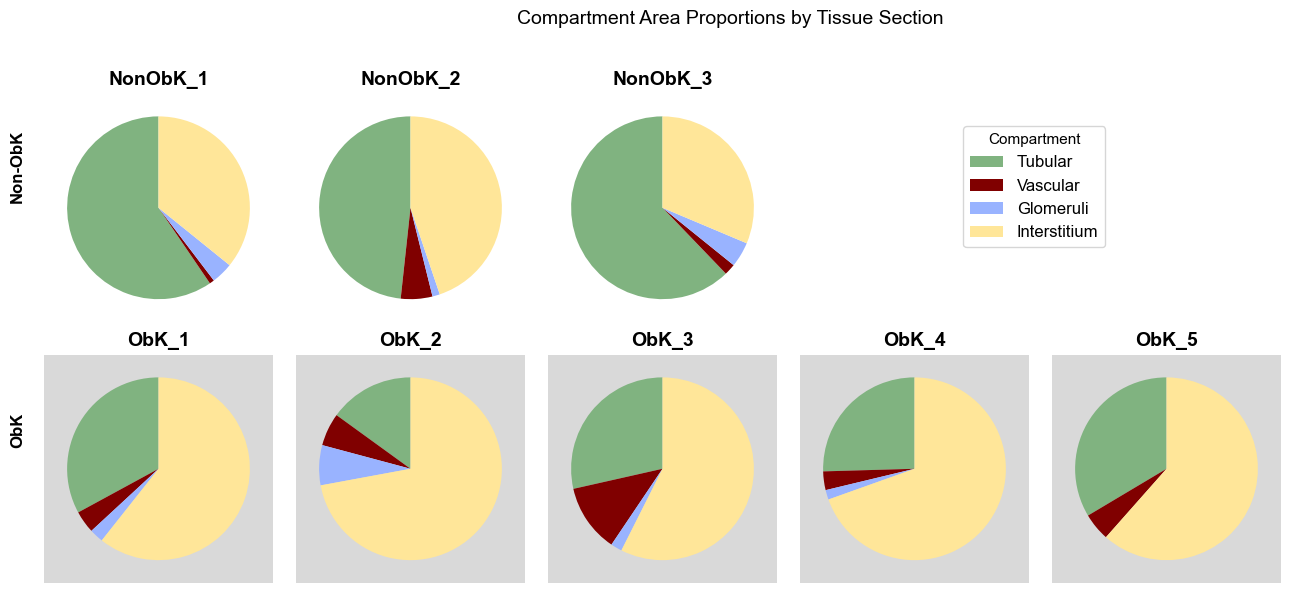

In [5]:
"""
Generate pie charts (one per tissue section) showing the proportion of
tissue area occupied by each compartment: Tubular (renamed from
"Tubule with Lumen"), Vascular, Glomeruli, and Interstitium.

The obstructed tissue sections are grouped together on a grey background;
the non-obstructed tissue sections are grouped together on a white background.
"""

COLORS = {
    "Tubular": "#80b380",       # was "Tubule with Lumen"
    "Vascular": "#800000",
    "Glomeruli": "#99b3ff",
    "Interstitium": "#ffe699",
}


# Order in which slices are drawn / labeled
COMPARTMENT_ORDER = ["Tubular", "Vascular", "Glomeruli", "Interstitium"]

# Rename map: TSV compartment name -> display name
RENAME = {
    "Tubule with Lumen": "Tubular",
    "Vascular": "Vascular",
    "Glomeruli": "Glomeruli",
    "Interstitium": "Interstitium",
}



# Keep only the compartments we're plotting, and rename them
df = df[df["Compartment"].isin(RENAME.keys())].copy()
df["Compartment"] = df["Compartment"].map(RENAME)

tissues = {}
tissue_order = []

for tissue, group in df.groupby("Tissue", sort=False):
    tissues[tissue] = {
        "category": group["Category"].iloc[0],
        "description": group["Description"].iloc[0],
        "data": dict(zip(group["Compartment"], group["Compartment_Area_um2"])),
    }
    tissue_order.append(tissue)

# Split into NonObK and ObK groups, sorted by the numeric suffix of the
# tissue section's description (e.g. ObK_1, ObK_2, ObK_3, ...)

def section_number(tissue_id):
    match = re.search(r"(\d+)$", tissues[tissue_id]["description"])
    return int(match.group(1)) if match else float("inf")

ok_tissues = sorted(
    (t for t in tissue_order if tissues[t]["category"] == "ObK"),
    key=section_number,
)
nk_tissues = sorted(
    (t for t in tissue_order if tissues[t]["category"] == "Non-ObK"),
    key=section_number,
)

# ----------------------------------------------------------------------
# 3. PLOT
# ----------------------------------------------------------------------
n_ok = len(ok_tissues)
n_nk = len(nk_tissues)
n_cols = max(n_ok, n_nk)

fig, axes = plt.subplots(2, n_cols, figsize=(3 * n_cols, 6))

def plot_pie(ax, tissue_id):
    values = [tissues[tissue_id]["data"][c] for c in COMPARTMENT_ORDER]
    colors = [COLORS[c] for c in COMPARTMENT_ORDER]
    ax.pie(
        values,
        colors=colors,
        startangle=90,
    )
    ax.set_title(tissues[tissue_id]["description"], fontsize=14, fontweight="bold")

# Row 1: Non-ObK tissues (white background)
for col in range(n_cols):
    ax = axes[0, col]
    if col < n_nk:
        plot_pie(ax, nk_tissues[col])
    ax.set_facecolor("white")
    ax.axis("off")
    ax.add_patch(
        plt.Rectangle(
            (0, 0), 1, 1, transform=ax.transAxes,
            facecolor="white", zorder=-1
        )
    )

# Row 2: OK tissues (grey background)
for col in range(n_cols):
    ax = axes[1, col]
    if col < n_ok:
        plot_pie(ax, ok_tissues[col])
    ax.set_facecolor("#d9d9d9")
    ax.axis("off") 
    ax.add_patch(
        plt.Rectangle(
            (0, 0), 1, 1, transform=ax.transAxes,
            facecolor="#d9d9d9", zorder=-1
        )
    )

fig.suptitle("Compartment Area Proportions by Tissue Section", fontsize=14, y=0.98)
fig.text(0.02, 0.72, "Non-ObK", fontsize=12, fontweight="bold", rotation=90, va="center")
fig.text(0.02, 0.28, "ObK", fontsize=12, fontweight="bold", rotation=90, va="center")

# Single color key in the corner
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=COLORS[c]) for c in COMPARTMENT_ORDER
]
fig.legend(
    legend_handles,
    COMPARTMENT_ORDER,
    loc="upper left",
    bbox_to_anchor=(0.65, 0.8),
    fontsize=12,
    title="Compartment",
    frameon=True,
)

# Leave room on the right for the legend and at the top for the title
plt.tight_layout(rect=[0.03, 0, 0.88, 0.95])
fig.savefig("compartment_pie_charts_DB.png", dpi=300, facecolor="white")
print("Saved compartment_pie_charts_DB.png")

### Plot for Fibronectin Percentages

Saved fibronectin_scatter_DB.png


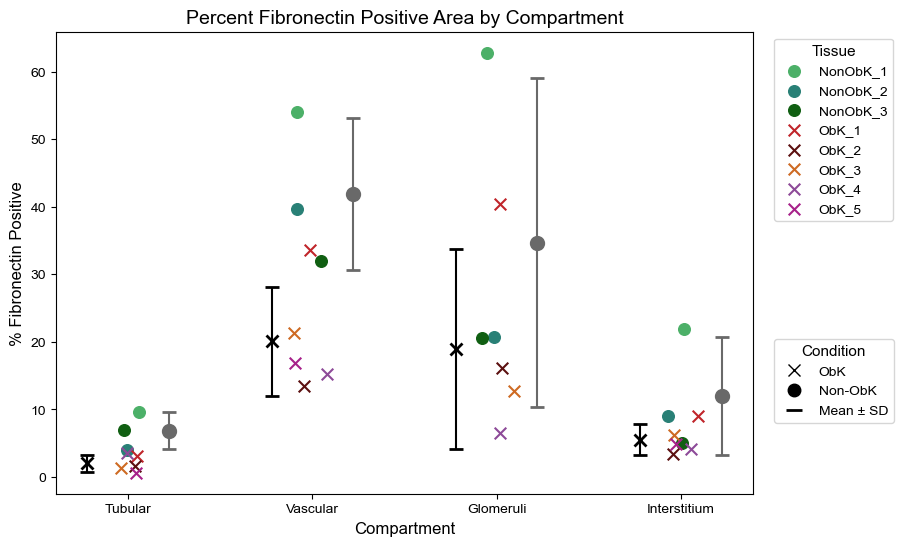

In [6]:
"""
Generate a scatter plot of %Fibronectin by compartment.

Compartments (Tubular, Vascular, Glomeruli, Interstitium) are on the x-axis,
%Fibronectin is on the y-axis. Points are colored by tissue Description, and
marker shape indicates category: ObK tissue sections are X's, Non-ObK tissue
sections are circles.

Mean +/- SD is also overlaid for each compartment, split by condition
(ObK vs Non-ObK), as black/gray error bars offset to either side of the
jittered raw points.

Formal statistics: for each compartment, ObK is compared against
Non-ObK using an unpaired (Welch) two-sample t-test -- unpaired
because ObK and Non-ObK are different tissue sections with no natural
matching between them, and Welch's version is used since the two
groups have unequal sample sizes (n=5 vs n=3, minus any sections
excluded per compartment as described below). The four compartment
comparisons are corrected for multiple testing with Holm-Bonferroni.
Significant comparisons (adjusted p < 0.05) are annotated on the plot;
the full comparison table (pairwise_stats_df) is built here and shown
in the next cell.

Sections with a compartment area of 0 um^2 (e.g. ObK_5 has no
glomeruli present) are excluded from that compartment's plot points
and statistics -- a 0 um^2 area means there was nothing to measure,
not a genuine 0% Fibronectin observation, so it is treated as missing
data rather than included as a data point.
"""

# One color per tissue Description
DESCRIPTION_COLORS = {
    "NonObK_1": "#4CB068",
    "NonObK_2": "#298076",
    "NonObK_3": "#105F12",
    "ObK_1": "#C0252A",
    "ObK_2": "#5B1010",
    "ObK_3": "#CE6A23",
    "ObK_4": "#8D4A98",
    "ObK_5": "#A7218A",
}

# Marker shape per category
MARKERS = {
    "ObK": "x",
    "Non-ObK": "o",
}

JITTER_WIDTH = 0.1  # horizontal jitter so overlapping points are visible
STAT_OFFSET = 0.22   # horizontal offset for mean/SD markers, per category

# ----------------------------------------------------------------------
# PLOT
# ----------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(9, 6))

x_positions = {c: i for i, c in enumerate(COMPARTMENT_ORDER)}
rng = np.random.default_rng(seed=3)  # fixed seed for reproducible jitter

# Exclude compartments with 0 um^2 measured area (e.g. ObK_5 has no
# glomeruli present). A 0 um^2 area is missing data -- there is nothing
# to compute a %Fibronectin value for -- not a genuine 0% observation,
# so these rows are dropped before plotting and before the stats below.
df_stats = df[df["Compartment_Area_um2"] > 0].copy()

for description, color in DESCRIPTION_COLORS.items():
    sub = df_stats[df_stats["Description"] == description]
    if sub.empty:
        continue
    category = sub["Category"].iloc[0]
    marker = MARKERS[category]

    x_vals = sub["Compartment"].map(x_positions).to_numpy(dtype=float)
    x_vals = x_vals + rng.uniform(-JITTER_WIDTH, JITTER_WIDTH, size=len(x_vals))
    ax2.scatter(
        x_vals,
        sub["Percent_Fibronectin"],
        color=color,
        marker=marker,
        label=description,
        s=70,
    )

# ----------------------------------------------------------------------
# DESCRIPTIVE STATISTICS: mean +/- SD per compartment, per category
# ----------------------------------------------------------------------
CATEGORY_STAT_OFFSETS = {
    "ObK": -STAT_OFFSET,
    "Non-ObK": STAT_OFFSET,
}
CATEGORY_STAT_COLORS = {
    "ObK": "black",
    "Non-ObK": "dimgray",
}

desc_stats = (
    df_stats.groupby(["Compartment", "Category"])["Percent_Fibronectin"]
    .agg(mean="mean", std="std")
    .reset_index()
)

for category, offset in CATEGORY_STAT_OFFSETS.items():
    cat_stats = desc_stats[desc_stats["Category"] == category]
    if cat_stats.empty:
        continue
    x_stat = cat_stats["Compartment"].map(x_positions).to_numpy(dtype=float) + offset
    ax2.errorbar(
        x_stat,
        cat_stats["mean"],
        yerr=cat_stats["std"],
        fmt=MARKERS[category],
        color=CATEGORY_STAT_COLORS[category],
        markersize=9,
        markeredgewidth=2,
        capsize=5,
        elinewidth=1.5,
        zorder=5,
    )

# ----------------------------------------------------------------------
# FORMAL STATISTICS: ObK vs Non-ObK, within each compartment.
# Unpaired (Welch) two-sample t-test, Holm-Bonferroni corrected across
# the four compartment comparisons.
# ----------------------------------------------------------------------

def holm_bonferroni(pvals):
    """Holm-Bonferroni step-down correction. Returns adjusted p-values
    in the same order as the input."""
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(n)
    running_max = 0.0
    for rank, idx in enumerate(order):
        val = (n - rank) * pvals[idx]
        running_max = max(running_max, val)
        adj[idx] = min(running_max, 1.0)
    return adj


def sig_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


comparison_rows = []
for compartment in COMPARTMENT_ORDER:
    comp_df = df_stats[df_stats["Compartment"] == compartment]
    obk_vals = comp_df.loc[comp_df["Category"] == "ObK", "Percent_Fibronectin"]
    nonobk_vals = comp_df.loc[comp_df["Category"] == "Non-ObK", "Percent_Fibronectin"]

    t_stat, p_val = ttest_ind(obk_vals, nonobk_vals, equal_var=False)
    comparison_rows.append({
        "Compartment": compartment,
        "n_ObK": len(obk_vals),
        "n_NonObK": len(nonobk_vals),
        "t_stat": t_stat,
        "p_value": p_val,
    })

p_adj = holm_bonferroni([r["p_value"] for r in comparison_rows])
for r, p in zip(comparison_rows, p_adj):
    r["p_adj_holm"] = p
    r["significance"] = sig_stars(p)

pairwise_stats_df = pd.DataFrame(comparison_rows)[[
    "Compartment", "n_ObK", "n_NonObK", "t_stat", "p_value",
    "p_adj_holm", "significance",
]]

# Annotate statistically significant (Holm-adjusted p < 0.05)
# compartments directly on the plot: a small bracket spanning the
# ObK/Non-ObK mean markers within that compartment.
y_top = ax2.get_ylim()[1]
bracket_step = y_top * 0.07
any_significant = False

for _, row in pairwise_stats_df.iterrows():
    if row["p_adj_holm"] >= 0.05:
        continue
    any_significant = True
    x_c = x_positions[row["Compartment"]]
    x1 = x_c + CATEGORY_STAT_OFFSETS["ObK"]
    x2 = x_c + CATEGORY_STAT_OFFSETS["Non-ObK"]
    y = y_top + bracket_step
    h = bracket_step * 0.15
    ax2.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color="black", linewidth=1.2)
    ax2.text(
        (x1 + x2) / 2, y + h, row["significance"],
        ha="center", va="bottom", fontsize=11, color="black",
    )

if any_significant:
    ax2.set_ylim(top=y_top + bracket_step * 2)

ax2.set_xticks(range(len(COMPARTMENT_ORDER)))
ax2.set_xticklabels(COMPARTMENT_ORDER)
ax2.set_xlabel("Compartment")
ax2.set_ylabel("% Fibronectin Positive")
ax2.set_title("Percent Fibronectin Positive Area by Compartment")

# Legend #1: tissue -> color
tissue_legend = ax2.legend(
    title="Tissue", bbox_to_anchor=(1.02, 1), loc="upper left"
)
ax2.add_artist(tissue_legend)  # keep this legend when the next one is added

# Legend #2: category -> marker shape (raw points) + mean +/- SD
category_handles = [
    plt.Line2D(
        [], [], color="black", marker=marker, linestyle="None",
        markersize=9, label=category,
    )
    for category, marker in MARKERS.items()
]
category_handles.append(
    plt.Line2D(
        [], [], color="black", marker="_", linestyle="None",
        markersize=12, markeredgewidth=2, label="Mean \u00b1 SD",
    )
)
category_legend = ax2.legend(
    handles=category_handles, title="Condition",
    bbox_to_anchor=(1.02, 0.35), loc="upper left",
)

fig2.savefig(
    "fibronectin_scatter_DB.png",
    dpi=200,
    facecolor="white",
    bbox_inches="tight",
    bbox_extra_artists=[tissue_legend, category_legend],
)
print("Saved fibronectin_scatter_DB.png")


Formal Statistics: ObK vs Non-ObK by Compartment

In [7]:
"""
Summary table of ObK vs Non-ObK comparisons underlying the
significance brackets on the fibronectin scatter plot above:
unpaired (Welch) two-sample t-test, Holm-Bonferroni corrected across
the four compartments.
"""

display_df = pairwise_stats_df.copy()
display_df["t_stat"] = display_df["t_stat"].round(3)
display_df["p_value"] = display_df["p_value"].round(4)
display_df["p_adj_holm"] = display_df["p_adj_holm"].round(4)

display(display_df)

display_df.to_csv("pairwise_compartment_stats_DB.csv", index=False)
print("Saved pairwise_compartment_stats_DB.csv")


,Compartment,n_ObK,n_NonObK,t_stat,p_value,p_adj_holm,significance
0,Tubular,5,3,-2.826,0.0817,0.2451,ns
1,Vascular,5,3,-2.939,0.0545,0.2181,ns
2,Glomeruli,4,3,-0.992,0.3922,0.6607,ns
3,Interstitium,5,3,-1.248,0.3303,0.6607,ns


Saved pairwise_compartment_stats_DB.csv
